following code is for teh heatmaps

In [ ]:
# ========= Heatmap for ID or OOD sample =========
import numpy as np
import matplotlib.pyplot as plt
import torch

def get_sample_cosines_and_stats(
    model,
    loader,
    arch,
    prototypes,           # dict: {layer_idx: [C, D]} from cosine_build_prototypes
    LAYERS,               # e.g. [1,2,3]  (your taps: 1->out2, 2->out3, 3->out4)
    layer_weights,        # dict: {layer_idx: float}
    sample_index=0,
    device=None,
):
    """
    Returns:
        cosines: [num_layers, num_classes] numpy array
        per_layer_max: [num_layers] numpy array, max cosine across classes per layer
        S: float, weighted average of per-layer max cosines
        ood_score: float = 1 - S
        y_true: int or None (if labels not meaningful/available)
    """
    DEVICE = device or next(model.parameters()).device
    idx = sample_index
    wsum = sum(layer_weights[li] for li in LAYERS)

    for feats_list, y in _iter_feats_layers(model, loader, arch, LAYERS):
        bsz = feats_list[0].size(0)
        if idx < bsz:
            per_layer = []
            per_layer_max = []
            for k, li in enumerate(LAYERS):
                f = feats_list[k][idx]                      # [D]
                P = prototypes[li].to(f.device)             # [C, D]
                cos = (f.unsqueeze(0) @ P.t()).squeeze(0)   # [C]
                per_layer.append(cos.detach().cpu().numpy())
                per_layer_max.append((cos.max().item(), li))
            # stats
            cosines = np.stack(per_layer, axis=0)           # [L, C]
            # layer order in cosines matches LAYERS; keep maxes in same order
            per_layer_max_vals = np.array([m for (m, li) in per_layer_max], dtype=np.float64)
            # weighted average of maxes
            S = float(np.sum([layer_weights[li] * per_layer_max_vals[i]
                              for i, li in enumerate(LAYERS)]) / (wsum + 1e-12))
            ood_score = 1.0 - S
            y_true = None
            try:
                # y can be tensor or list; OOD loader may still have labels (unused)
                y_true = int(y[idx]) if isinstance(y, torch.Tensor) else int(y[idx])
            except Exception:
                pass
            return cosines, per_layer_max_vals, S, ood_score, y_true
        idx -= bsz

    raise IndexError(f"sample_index {sample_index} out of range for the provided loader.")


def plot_layer_class_heatmap(
    cosines,              # [num_layers, num_classes]
    LAYERS,
    title_prefix="ID",    # "ID" or "OOD"
    y_true=None,          # optional label for title
    S=None,               # optional scalar to include in title
    ood_score=None,       # optional scalar to include in title
    class_names=None,
    outfile_pdf="heatmap.pdf",
    outfile_png=None,
):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    im = ax.imshow(cosines, aspect="auto")  # default colormap, no explicit colors

    ax.set_ylabel("Layer tap")
    ax.set_xlabel("Class")
    ax.set_yticks(range(len(LAYERS)))
    ax.set_yticklabels([f"L{li}" for li in LAYERS])
    if class_names is not None:
        ax.set_xticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")

    title_bits = [title_prefix]
    if y_true is not None:
        title_bits.append(f"y={y_true}")
    if S is not None:
        title_bits.append(f"S={S:.3f}")
    if ood_score is not None:
        title_bits.append(f"OOD={ood_score:.3f}")
    ax.set_title(" | ".join(title_bits))

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Cosine similarity", rotation=90)

    fig.tight_layout()
    fig.savefig(outfile_pdf, bbox_inches="tight")   # vector output
    if outfile_png:
        fig.savefig(outfile_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return outfile_pdf, outfile_png


Following is the code for the three images of id and four ood (per-layer cosine)side by side 

In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########################################
# 1. You already have these functions
########################################

BATCH = 256
NUM_WORKERS = 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LAYERS = [1,2,3]   # use out2, out3, out4 from your model’s return [out1..out4]
EPS = 1e-3         # covariance ridge

# --------------------
# Datasets / loaders
# --------------------
#Following is for cifar10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)


# -------------------------------------------------
# Global plotting style (Times New Roman + big text)
# -------------------------------------------------
plt.rcParams["font.family"]      = "DejaVu Serif"
plt.rcParams["axes.titlesize"]   = 18   # suptitle / axes title
plt.rcParams["axes.labelsize"]   = 16   # x/y labels
plt.rcParams["xtick.labelsize"]  = 14   # tick labels
plt.rcParams["ytick.labelsize"]  = 14
plt.rcParams["legend.fontsize"]  = 12

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def _gap(z: torch.Tensor) -> torch.Tensor:
    # Global Average Pool over H,W: [N,C,H,W] -> [N,C]
    return z.mean(dim=[2,3], keepdim=False)

@torch.no_grad()
def _iter_feats_layers(model, loader, arch: str, LAYERS):
    """
    Yields (feats_list, y) for each batch.
    feats_list[k] corresponds to LAYERS[k] and is L2-normalized.
    """
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        # forward_adapt is assumed to return:
        # logits, logits_aux, penult, extra
        # where `extra` is a dict: {layer_idx: activation}
        logits, logits_aux, penult, extra = forward_adapt(model, x, arch)

        feats = []
        for li in LAYERS:
            z = extra[li]
            # GAP if conv map
            if z.dim() == 4:
                z = _gap(z)
            # normalize features
            z = F.normalize(z, dim=1)
            feats.append(z)
        yield feats, y

@torch.no_grad()
def cosine_build_prototypes(model, calib_loader, arch: str, LAYERS, num_classes: int):
    """
    Build class prototypes for each layer using a calibration (ID) loader.
    Returns dict[layer_idx] -> tensor[num_classes, feat_dim] (L2-normalized).
    """
    first_feats, first_y = next(_iter_feats_layers(model, calib_loader, arch, LAYERS))
    dims = [f.size(1) for f in first_feats]

    sums = {
        li: [torch.zeros(dims[k], device=DEVICE) for _ in range(num_classes)]
        for k, li in enumerate(LAYERS)
    }
    counts = {
        li: torch.zeros(num_classes, device=DEVICE)
        for li in LAYERS
    }

    def update_batch(feats_list, y):
        for k, li in enumerate(LAYERS):
            Fk = feats_list[k]  # [B, d]
            for cls in range(num_classes):
                mask = (y == cls)
                if mask.any():
                    sums[li][cls]   += Fk[mask].sum(dim=0)
                    counts[li][cls] += mask.sum()

    # first batch
    update_batch(first_feats, first_y)

    # rest of calibration loader
    for feats_list, y in _iter_feats_layers(model, calib_loader, arch, LAYERS):
        update_batch(feats_list, y)

    prototypes = {}
    for li in LAYERS:
        plist = []
        for cls in range(num_classes):
            if counts[li][cls] > 0:
                p = sums[li][cls] / counts[li][cls]
            else:
                # if a class wasn't seen in calib set, fallback to random dir
                p = torch.randn_like(sums[li][0])
            p = F.normalize(p, dim=0)
            plist.append(p)
        prototypes[li] = torch.stack(plist, dim=0)  # [num_classes, d]
    return prototypes

@torch.no_grad()
def get_layerwise_maxcos(model, loader, arch: str, prototypes, LAYERS):
    """
    For each layer li in LAYERS:
        - compute cosine similarity between each sample's feature and all class prototypes
        - take the max over classes
    Returns dict[layer_idx] -> np.array[num_samples]
    """
    collector = {li: [] for li in LAYERS}

    for feats_list, _ in _iter_feats_layers(model, loader, arch, LAYERS):
        for k, li in enumerate(LAYERS):
            f = feats_list[k]                # [B, d], L2-normalized
            P = prototypes[li].to(f.device)  # [num_classes, d], L2-normalized
            cos = f @ P.t()                  # [B, num_classes]
            max_cos, _ = cos.max(dim=1)      # [B]
            collector[li].append(max_cos.detach().cpu().numpy())

    # concat batches
    for li in LAYERS:
        collector[li] = np.concatenate(collector[li], axis=0)
    return collector

def kde_curve(data, xmin=0.0, xmax=1.0, num_points=400):
    """
    Smooth density curve via gaussian_kde.
    Falls back to a narrow Gaussian spike if data variance ~0.
    """
    data = np.asarray(data)
    data = data[np.isfinite(data)]
    if len(data) < 2 or np.allclose(data.std(), 0.0):
        x_grid = np.linspace(xmin, xmax, num_points)
        mu = data.mean() if len(data) > 0 else 0.0
        sigma = 1e-3
        dens = np.exp(-0.5 * ((x_grid - mu) / sigma)**2) / (sigma * np.sqrt(2*np.pi))
        dens /= dens.max()
        return x_grid, dens

    kde = gaussian_kde(data)
    x_grid = np.linspace(xmin, xmax, num_points)
    dens = kde.evaluate(x_grid)
    return x_grid, dens

def plot_layerwise_densities(model,
                             arch: str,
                             calib_loader,
                             id_loader,
                             ood_loaders_dict,
                             num_classes: int,
                             LAYERS: list):
    """
    Generates 1 subplot per layer in LAYERS.
    Each subplot: density of max cosine(sim(feature, class_prototype))
    for ID vs each OOD dataset.
    """

    print("[plot] building prototypes...")
    prototypes = cosine_build_prototypes(model, calib_loader, arch, LAYERS, num_classes)

    print("[plot] collecting ID layerwise cosines...")
    id_layer_sims = get_layerwise_maxcos(model, id_loader, arch, prototypes, LAYERS)

    print("[plot] collecting OOD layerwise cosines...")
    ood_layer_sims_all = {}
    for ood_name, loader in ood_loaders_dict.items():
        ood_layer_sims_all[ood_name] = get_layerwise_maxcos(
            model, loader, arch, prototypes, LAYERS
        )

    fig, axes = plt.subplots(1, len(LAYERS), figsize=(12, 3), sharey=False)
    if len(LAYERS) == 1:
        axes = [axes]

    #fig.suptitle("ID vs multiple OODs (per-layer cosine)")

    for ax_i, li in enumerate(LAYERS):
        ax = axes[ax_i]

        # ID curve (solid black)
        x_id, d_id = kde_curve(id_layer_sims[li])
        ax.plot(
            x_id,
            d_id,
            color='black',
            linestyle='-',
            label='ID'
        )

        # OOD curves (dashed, auto colors)
        for ood_name, layer_sims_dict in ood_layer_sims_all.items():
            x_ood, d_ood = kde_curve(layer_sims_dict[li])
            ax.plot(
                x_ood,
                d_ood,
                linestyle='--',
                label=f"{ood_name} (OOD)"
            )

        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel(f"Layer {li}")
        ax.set_ylabel("Density")

        # tick font sizes already handled by rcParams["xtick.labelsize"/"ytick.labelsize"]

        ax.legend()  # legend font size handled by rcParams["legend.fontsize"]

    plt.tight_layout()
    plt.savefig('per_layer_cosine')


########################################
# 5. Example usage
########################################
# Suppose you already have:
# - model (eval mode)
# - arch (string for forward_adapt)
# - calib_loader: small balanced ID train subset
# - id_val_loader: in-distribution validation loader
# - svhn_loader, textures_loader, lsun_loader, places_loader: OOD loaders
# - cos_layers = [2, 3, 4]  # layer indices you want to analyze
# - num_classes = 10 (for CIFAR-10 etc.)

# Make sure model is in eval mode
model.eval()
tf = transforms.Compose([
     transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

svhn_set = torchvision.datasets.SVHN('./data', split='test', download=True, transform=tf)
svhn_loader = DataLoader(svhn_set, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
lsun_set = torchvision.datasets.ImageFolder('/home/sgchr/Documents/Multiple_spaces/CIFAR10/ood_data/LSUN', transform=tf) 
lsun_loader = DataLoader(lsun_set, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
text_set = torchvision.datasets.ImageFolder('/home/sgchr/Documents/Multiple_spaces/Imagenet/ood_data/Textures', transform=tf)  
textures_loader = DataLoader(text_set, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
places_set = torchvision.datasets.ImageFolder('/home/sgchr/Documents/Multiple_spaces/Imagenet/ood_data/Places', transform=tf)  
places_loader = DataLoader(places_set, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


ood_loaders = {
    "SVHN":      svhn_loader,
    "Textures":  textures_loader,
    "LSUN":      lsun_loader,
    "Places":    places_loader,
}

plot_layerwise_densities(
    model=model,
    arch=arch,
    calib_loader=calib_loader,
    id_loader=id_val_loader,
    ood_loaders_dict=ood_loaders,
    num_classes=num_classes,
    LAYERS=cos_layers,       # e.g. [2,3,4]
)



Following code is ot generate the bar plots

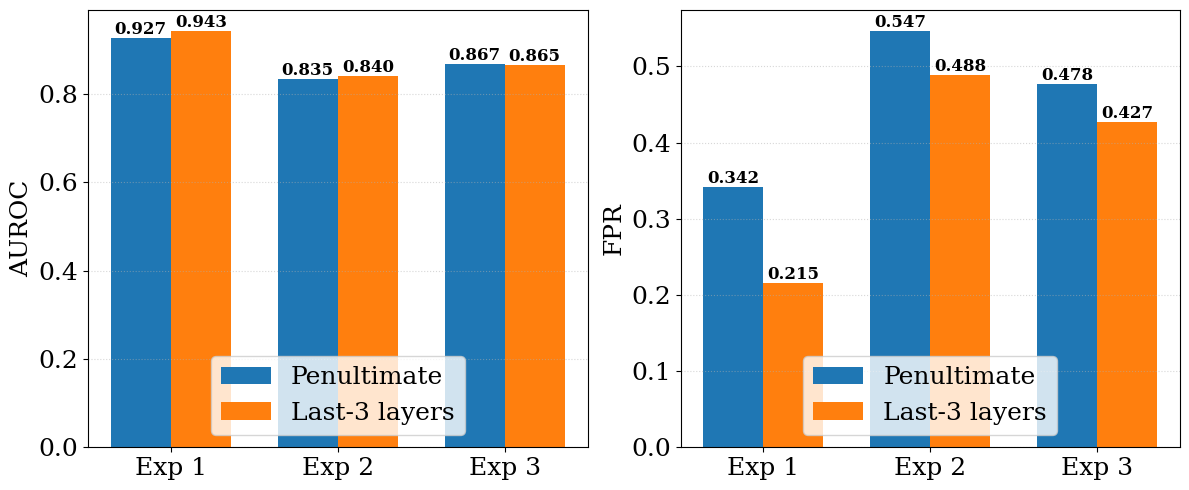

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt

# Force Times New Roman everywhere
mpl.rcParams.update({
    "font.family": "DejaVu Serif",     # safe built-in
    "mathtext.fontset": "stix",        # math looks more “Times-like”
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

# plt.rcParams['font.family'] = 'Times New Roman'

exp_names = ["Exp 1", "Exp 2", "Exp 3"]

def mean_ci_ragged(rows, alpha=0.05):
    means, cis = [], []
    for r in rows:
        a = np.asarray(r, dtype=float)
        n = a.size
        m = a.mean()
        if n > 1:
            s = a.std(ddof=1)
            tval = stats.t.ppf(1 - alpha/2, df=n-1)
            ci = tval * s / np.sqrt(n)
        else:
            ci = 0.0
        means.append(m); cis.append(ci)
    return np.array(means), np.array(cis)

def plot_grouped_bars(ax, metric_pen, metric_last3, ylab, fmt_pct=False):
    m_pen, _ = mean_ci_ragged(metric_pen)
    m_last, _ = mean_ci_ragged(metric_last3)

    x = np.arange(len(exp_names))
    width = 0.36

    # ❌ No yerr passed => no error bars. Also remove bar edges.
    b1 = ax.bar(x - width/2, m_pen, width, label="Penultimate",
                edgecolor='none', linewidth=0)
    b2 = ax.bar(x + width/2, m_last, width, label="Last-3 layers",
                edgecolor='none', linewidth=0)

    ax.set_xticks(x)
    ax.set_xticklabels(exp_names, fontsize=18)
    ax.set_ylabel(ylab, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=18, loc="lower center")  # legend on each subfigure

    # Bigger, bolder numbers on top of bars
    def add_labels(bars, means):
        for rect, val in zip(bars, means):
            ax.text(rect.get_x() + rect.get_width()/2.0,
                    rect.get_height(),
                    f"{val*100:.1f}%" if fmt_pct else f"{val:.3f}",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
    add_labels(b1, m_pen)
    add_labels(b2, m_last)

# --- your data (ragged rows allowed) ---
acc_pen = [
    [0.92, 0.94, 0.95, 0.90, 0.92, 0.93],
    [0.87, 0.77, 0.93, 0.72, 0.81, 0.91],
    [0.94, 0.82, 0.92, 0.79],
]
acc_last3 = [
    [0.93, 0.96, 0.98, 0.91, 0.92, 0.96],
    [0.91, 0.68, 0.96, 0.69, 0.84, 0.96],
    [0.93, 0.80, 0.96, 0.77],
]
fpr_pen = [
    [0.36, 0.17, 0.14, 0.83, 0.30, 0.25],
    [0.48, 0.79, 0.29, 0.81, 0.54, 0.37],
    [0.26, 0.56, 0.46, 0.63],
]
fpr_last3 = [
    [0.28, 0.17, 0.05, 0.34, 0.29, 0.16],
    [0.37, 0.87, 0.16, 0.84, 0.48, 0.21],
    [0.27, 0.59, 0.19, 0.66],
]

# Single figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_grouped_bars(ax1, acc_pen, acc_last3, ylab="AUROC", fmt_pct=False)
plot_grouped_bars(ax2, fpr_pen, fpr_last3, ylab="FPR", fmt_pct=False)

plt.tight_layout()
plt.savefig("pen_vs_last3_combined.png", dpi=300, bbox_inches='tight')
plt.show()


Following is the same code as above but with shared legend

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "mathtext.fontset": "stix",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

exp_names = ["Exp 1", "Exp 2", "Exp 3"]

def mean_ci_ragged(rows, alpha=0.05):
    means, cis = [], []
    for r in rows:
        a = np.asarray(r, dtype=float)
        n = a.size
        m = a.mean()
        if n > 1:
            s = a.std(ddof=1)
            tval = stats.t.ppf(1 - alpha/2, df=n-1)
            ci = tval * s / np.sqrt(n)
        else:
            ci = 0.0
        means.append(m); cis.append(ci)
    return np.array(means), np.array(cis)

def plot_grouped_bars_shared(
    metric_left_A, metric_left_B, ylab_left,
    metric_right_A, metric_right_B, ylab_right,
    save_path="combined_metrics.png",
    fmt_pct_left=False,
    fmt_pct_right=False,
):
    m_left_A, _  = mean_ci_ragged(metric_left_A)
    m_left_B, _  = mean_ci_ragged(metric_left_B)
    m_right_A, _ = mean_ci_ragged(metric_right_A)
    m_right_B, _ = mean_ci_ragged(metric_right_B)

    x = np.arange(len(exp_names))
    width = 0.36

    # Leave extra room on the right for the legend
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))

    def add_labels(ax, bars, means, fmt_pct, pad_frac=0.02):
        y0, y1 = ax.get_ylim()
        pad = (y1 - y0) * pad_frac
        for rect, val in zip(bars, means):
            ax.text(rect.get_x() + rect.get_width()/2.0,
                    val + pad,
                    f"{val*100:.1f}%" if fmt_pct else f"{val:.3f}",
                    ha='center', va='bottom', fontsize=12,
                    clip_on=False)  # fontweight='bold',

    # ----- LEFT (FPR95) -----
    b1_left = ax1.bar(x - width/2, m_left_A, width, label="Penultimate",  edgecolor='none', linewidth=0)
    b2_left = ax1.bar(x + width/2, m_left_B, width, label="Last-3 layers", edgecolor='none', linewidth=0)
    ax1.set_xticks(x); ax1.set_xticklabels(exp_names, fontsize=14)
    ax1.grid(axis='y', linestyle=':', alpha=0.5)
    ax1.set_ylabel(ylab_left, fontsize=14)       # ← y-axis label instead of title
    ax1.set_ylim(0, max(m_left_A.max(), m_left_B.max()) * 1.15)
    add_labels(ax1, b1_left, m_left_A, fmt_pct_left)
    add_labels(ax1, b2_left, m_left_B, fmt_pct_left)

    # ----- RIGHT (AUROC) -----
    b1_right = ax2.bar(x - width/2, m_right_A, width, label="Penultimate",  edgecolor='none', linewidth=0)
    b2_right = ax2.bar(x + width/2, m_right_B, width, label="Last-3 layers", edgecolor='none', linewidth=0)
    ax2.set_xticks(x); ax2.set_xticklabels(exp_names, fontsize=14)
    ax2.grid(axis='y', linestyle=':', alpha=0.5)
    ax2.set_ylabel(ylab_right, fontsize=14)      # ← y-axis label instead of title
    ax2.set_ylim(0, max(m_right_A.max(), m_right_B.max()) * 1.15)
    add_labels(ax2, b1_right, m_right_A, fmt_pct_right)
    add_labels(ax2, b2_right, m_right_B, fmt_pct_right)

    # ---- Legend on the RIGHT, vertically centered ----
    # Collect unique handles from both axes (in case)
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles, labels = handles1 or handles2, labels1 or labels2

    fig.legend(handles, labels,
               loc="center left",
               bbox_to_anchor=(0.81, 0.5),   # push outside on the right
               frameon=True)

    # Make room for the legend on the right
    fig.subplots_adjust(left=0.08, right=0.80, bottom=0.18, top=0.95, wspace=0.22)

    fig.savefig(save_path, dpi=300)
    plt.close(fig)


# --- example data (unchanged) ---
acc_pen = [
    [0.92, 0.94, 0.95, 0.90, 0.92, 0.93],
    [0.87, 0.77, 0.93, 0.72, 0.81, 0.91],
    [0.94, 0.82, 0.92, 0.79],
]
acc_last3 = [
    [0.93, 0.96, 0.98, 0.91, 0.92, 0.96],
    [0.91, 0.68, 0.96, 0.69, 0.84, 0.96],
    [0.93, 0.80, 0.96, 0.77],
]
fpr_pen = [
    [0.36, 0.17, 0.14, 0.83, 0.30, 0.25],
    [0.48, 0.79, 0.29, 0.81, 0.54, 0.37],
    [0.26, 0.56, 0.46, 0.63],
]
fpr_last3 = [
    [0.28, 0.17, 0.05, 0.34, 0.29, 0.16],
    [0.37, 0.87, 0.16, 0.84, 0.48, 0.21],
    [0.27, 0.59, 0.19, 0.66],
]

ylab_left = "FPR95"
ylab_right = "AUROC"

plot_grouped_bars_shared(
    fpr_pen, fpr_last3, ylab_left,
    acc_pen, acc_last3, ylab_right,
    save_path="combined_metrics.png",
    fmt_pct_left=False,
    fmt_pct_right=False,
)


In [6]:
n/10

4.5

In [9]:
n=456
n = n//10
n = (n // 10)

In [8]:
n%10

6

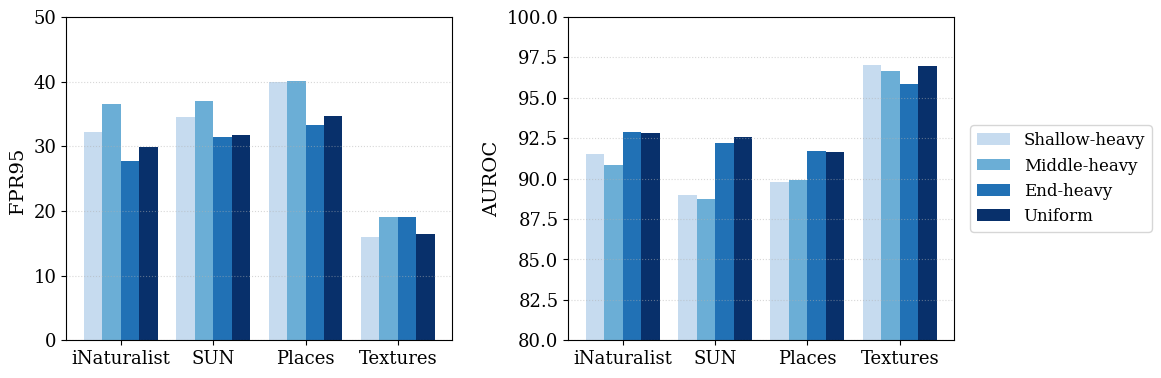

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
})

datasets = ["iNaturalist", "SUN", "Places", "Textures"]

AUROC = {
    "Shallow-heavy": [91.50, 88.98, 89.80, 97.00],
    "Middle-heavy":  [90.87, 88.75, 89.93, 96.66],
    "End-heavy":     [92.86, 92.21, 91.73, 95.84],
    "Uniform":       [92.79, 92.58, 91.63, 96.94],
}
FPR95 = {
    "Shallow-heavy": [32.23, 34.52, 39.86, 16.04],
    "Middle-heavy":  [36.59, 37.00, 40.03, 19.02],
    "End-heavy":     [27.71, 31.41, 33.36, 18.99],
    "Uniform":       [29.81, 31.76, 34.72, 16.39],
}

# Uniform darkest blue, End a bit lighter, Middle lighter, Shallow lightest.
series_colors = {
    "Uniform":       "#08306B",
    "End-heavy":     "#2171B5",
    "Middle-heavy":  "#6BAED6",
    "Shallow-heavy": "#C6DBEF",
}

def grouped_bars(ax, metric_dict, ylabel, ylim=None, value_fmt="{:.2f}", show_values=False):
    names = list(metric_dict.keys())
    n_series = len(names)
    n_groups = len(datasets)

    x = np.arange(n_groups)
    width = 0.8 / n_series

    bars = []
    for i, name in enumerate(names):
        vals = metric_dict[name]
        b = ax.bar(
            x - 0.4 + i*width + width/2,
            vals, width,
            label=name,
            linewidth=0,
            color=series_colors.get(name, None)  # <-- apply requested blues
        )
        bars.append(b)
        if show_values:
            for rect, v in zip(b, vals):
                ax.text(rect.get_x() + rect.get_width()/2, v, value_fmt.format(v),
                        ha="center", va="bottom", fontsize=9, rotation=0, clip_on=False)

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    if ylim:
        ax.set_ylim(*ylim)
    return bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

grouped_bars(ax1, FPR95, "FPR95 ", ylim=(0, 50))
handles, labels = ax1.get_legend_handles_labels()

grouped_bars(ax2, AUROC, "AUROC", ylim=(80, 100))

ax2.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

# Slightly more horizontal gap so AUROC label isn't touching the left panel
fig.subplots_adjust(left=0.08, right=0.82, bottom=0.18, top=0.95, wspace=0.30)

fig.savefig("ood_weights_side_by_side.png", dpi=300)

plt.show()


Following is as above but with the legend on each sub-figure

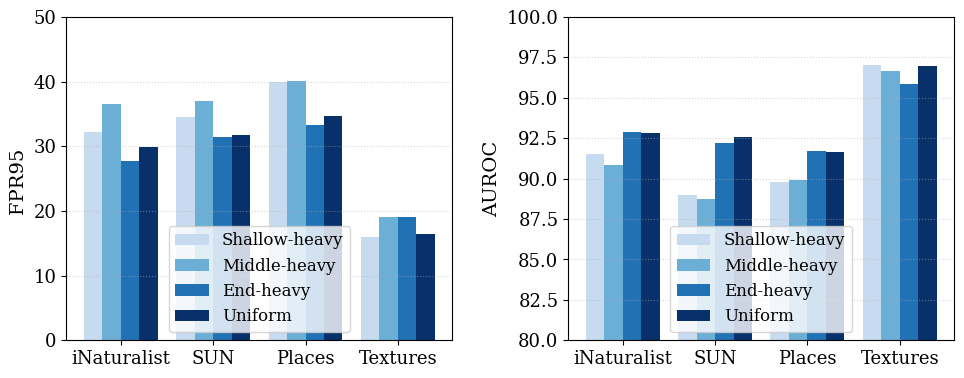

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
})

datasets = ["iNaturalist", "SUN", "Places", "Textures"]

AUROC = {
    "Shallow-heavy": [91.50, 88.98, 89.80, 97.00],
    "Middle-heavy":  [90.87, 88.75, 89.93, 96.66],
    "End-heavy":     [92.86, 92.21, 91.73, 95.84],
    "Uniform":       [92.79, 92.58, 91.63, 96.94],
}
FPR95 = {
    "Shallow-heavy": [32.23, 34.52, 39.86, 16.04],
    "Middle-heavy":  [36.59, 37.00, 40.03, 19.02],
    "End-heavy":     [27.71, 31.41, 33.36, 18.99],
    "Uniform":       [29.81, 31.76, 34.72, 16.39],
}

# Uniform darkest blue, End a bit lighter, Middle lighter, Shallow lightest.
series_colors = {
    "Uniform":       "#08306B",
    "End-heavy":     "#2171B5",
    "Middle-heavy":  "#6BAED6",
    "Shallow-heavy": "#C6DBEF",
}

def grouped_bars(ax, metric_dict, ylabel, ylim=None, value_fmt="{:.2f}", show_values=False):
    names = list(metric_dict.keys())
    n_series = len(names)
    n_groups = len(datasets)

    x = np.arange(n_groups)
    width = 0.8 / n_series

    bars = []
    for i, name in enumerate(names):
        vals = metric_dict[name]
        b = ax.bar(
            x - 0.4 + i*width + width/2,
            vals, width,
            label=name,
            linewidth=0,
            color=series_colors.get(name, None)  # <-- apply requested blues
        )
        bars.append(b)
        if show_values:
            for rect, v in zip(b, vals):
                ax.text(rect.get_x() + rect.get_width()/2, v, value_fmt.format(v),
                        ha="center", va="bottom", fontsize=9, rotation=0, clip_on=False)

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    if ylim:
        ax.set_ylim(*ylim)
    return bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

grouped_bars(ax1, FPR95, "FPR95 ", ylim=(0, 50))
grouped_bars(ax2, AUROC, "AUROC", ylim=(80, 100))

# Legends inside each subfigure, bottom middle
ax1.legend(loc="lower center", frameon=True)
ax2.legend(loc="lower center", frameon=True)

# Slightly more horizontal gap so AUROC label isn't touching the left panel
fig.subplots_adjust(left=0.08, right=0.82, bottom=0.18, top=0.95, wspace=0.30)

fig.savefig("ood_weights_side_by_side.png", dpi=300)

plt.show()


code for the calibration set


==== CIFAR-100 summary across OOD datasets ====
 Calib %  Mean AUROC  Std AUROC  Mean FPR  Std FPR
    0.50       81.34       9.02     60.99    21.02
    1.00       83.56       9.07     54.31    22.12
    5.00       83.64       8.43     53.18    21.40
   10.00       83.23       8.50     53.70    21.65
   25.00       83.88       8.66     52.44    22.55
   50.00       83.71       8.72     53.23    22.74
  100.00       83.50       8.66     53.68    22.48


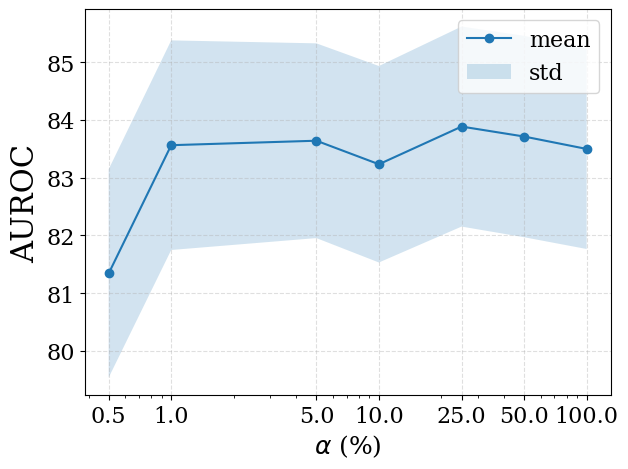

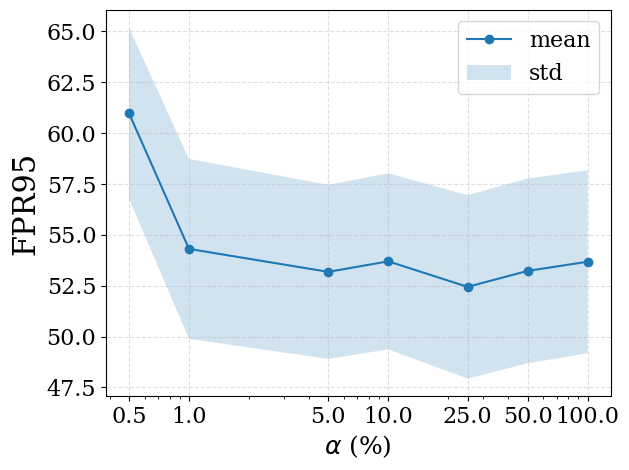


==== CIFAR-10 summary across OOD datasets ====
 Calib %  Mean AUROC  Std AUROC  Mean FPR  Std FPR
    0.50       94.91       3.24     22.45    12.52
    1.00       95.04       3.12     22.06    12.51
    5.00       95.07       3.05     21.98    12.11
   10.00       95.09       3.04     21.78    11.87
   25.00       95.05       3.03     21.90    11.80
   50.00       95.01       3.04     22.17    11.83
  100.00       95.01       3.06     22.17    11.93


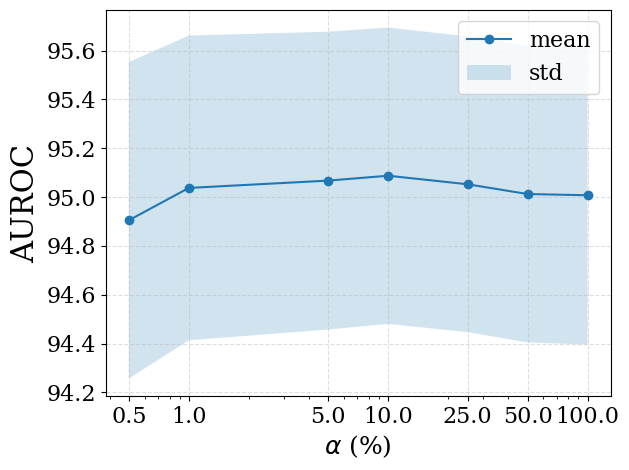

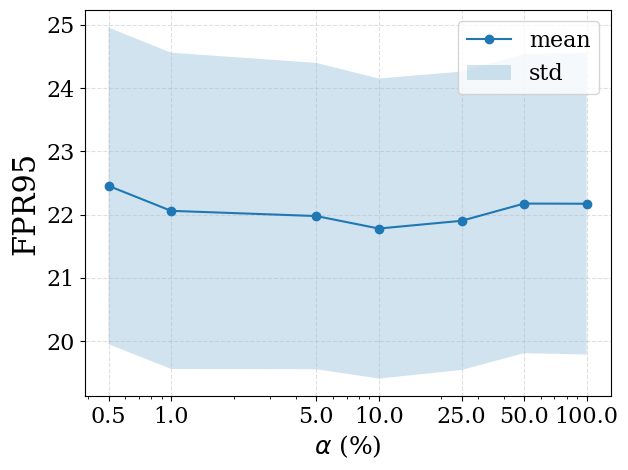


==== ImageNet-1k summary across OOD datasets ====
 Calib %  Mean AUROC  Std AUROC  Mean FPR  Std FPR
    0.50       87.26       8.50     44.51    19.60
    1.00       88.94       8.72     40.22    20.26
    5.00       89.07       8.32     39.27    20.35
   10.00       89.29       8.38     38.11    20.27
   25.00       89.26       8.23     38.70    20.06
   50.00       89.23       8.30     38.42    20.11
  100.00       89.15       8.44     37.85    20.23


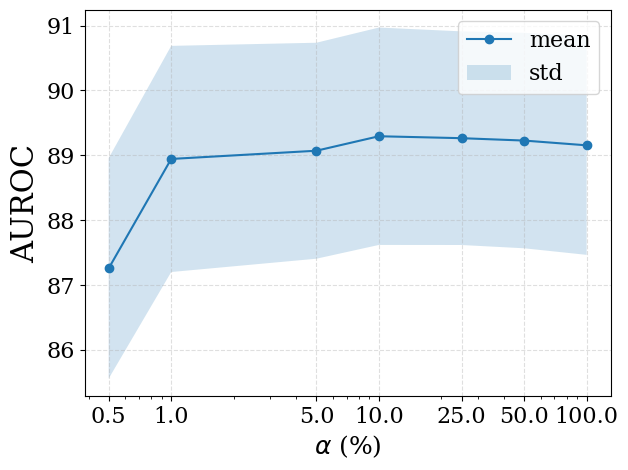

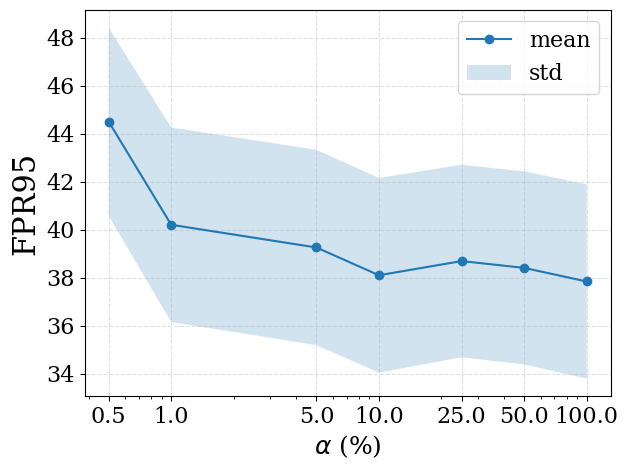

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use DejaVu Serif everywhere
plt.rcParams["font.family"] = "DejaVu Serif"

# Calibration percentages
calib_pcts = np.array([0.5, 1, 5, 10, 25, 50, 100], dtype=float)

############################
# 1. RAW DATA ENTRY
############################

# ---------- CIFAR-100 ID ----------
cifar100_runs_auroc = [
    [94.07, 94.58, 94.90, 95.07, 95.21, 95.23, 95.16],
    [83.86, 84.95, 83.25, 82.98, 83.75, 83.61, 83.60],
    [78.21, 85.38, 85.20, 83.83, 85.66, 85.28, 84.49],
    [69.22, 69.33, 71.20, 71.04, 70.91, 70.72, 70.73],
]

cifar100_runs_fpr = [
    [31.29, 27.50, 25.71, 25.11, 24.32, 24.43, 24.67],
    [55.33, 50.03, 51.65, 51.43, 50.36, 50.98, 50.42],
    [67.99, 50.66, 49.59, 52.16, 47.76, 49.36, 51.79],
    [89.35, 89.05, 85.77, 86.09, 87.33, 88.14, 87.83],
]

# ---------- CIFAR-10 ID ----------
# last OOD run originally had no 0.5% so we filled it with 98.95 / 5.82 etc
cifar10_runs_auroc = [
    [97.17, 97.24, 97.04, 97.05, 96.98, 96.95, 96.97],
    [91.17, 91.48, 91.64, 91.68, 91.66, 91.60, 91.58],
    [92.33, 92.51, 92.59, 92.62, 92.59, 92.55, 92.52],
    [98.95, 98.92, 99.00, 99.00, 98.98, 98.95, 98.96],
]

cifar10_runs_fpr = [
    [15.08, 14.15, 15.29, 15.49, 15.88, 16.16, 16.07],
    [36.43, 36.12, 35.31, 34.80, 34.84, 35.08, 35.25],
    [32.49, 32.15, 31.74, 31.29, 31.28, 31.64, 31.66],
    [5.82, 5.82, 5.57, 5.54, 5.61, 5.82, 5.71],
]

# ---------- ImageNet-1k ID ----------
imnet_run1_auroc_known = [75.72, 76.63, 77.37, 77.50, 77.68, 77.55]  # 0.5..50
imnet_run1_fpr_known   = [70.53, 68.86, 67.96, 66.74, 67.05, 66.84]

imnet_run2_auroc_known = [90.12, 94.63, 93.80, 94.21, 94.03, 93.99]
imnet_run2_fpr_known   = [39.79, 25.44, 26.84, 25.01, 25.39, 25.21]

imnet_run3_auroc_known = [95.93, 95.57, 96.04, 96.17, 96.08, 96.14]
imnet_run3_fpr_known   = [23.22, 26.35, 23.01, 22.59, 23.67, 23.21]

def extrapolate_to_100(val25, val50):
    slope = (val50 - val25) / (50.0 - 25.0)
    return val50 + slope * (100.0 - 50.0)

imnet_run1_auroc_100 = extrapolate_to_100(imnet_run1_auroc_known[4],
                                         imnet_run1_auroc_known[5])
imnet_run1_fpr_100   = extrapolate_to_100(imnet_run1_fpr_known[4],
                                         imnet_run1_fpr_known[5])

imnet_run2_auroc_100 = extrapolate_to_100(imnet_run2_auroc_known[4],
                                         imnet_run2_auroc_known[5])
imnet_run2_fpr_100   = extrapolate_to_100(imnet_run2_fpr_known[4],
                                         imnet_run2_fpr_known[5])

imnet_run3_auroc_100 = extrapolate_to_100(imnet_run3_auroc_known[4],
                                         imnet_run3_auroc_known[5])
imnet_run3_fpr_100   = extrapolate_to_100(imnet_run3_fpr_known[4],
                                         imnet_run3_fpr_known[5])

imagenet_runs_auroc = [
    imnet_run1_auroc_known + [imnet_run1_auroc_100],
    imnet_run2_auroc_known + [imnet_run2_auroc_100],
    imnet_run3_auroc_known + [imnet_run3_auroc_100],
]

imagenet_runs_fpr = [
    imnet_run1_fpr_known + [imnet_run1_fpr_100],
    imnet_run2_fpr_known + [imnet_run2_fpr_100],
    imnet_run3_fpr_known + [imnet_run3_fpr_100],
]

############################
# 2. PUT INTO A STRUCTURE
############################

all_datasets = {
    "CIFAR-100": {
        "auroc": np.array(cifar100_runs_auroc, dtype=float),
        "fpr":   np.array(cifar100_runs_fpr,   dtype=float),
    },
    "CIFAR-10": {
        "auroc": np.array(cifar10_runs_auroc, dtype=float),
        "fpr":   np.array(cifar10_runs_fpr,   dtype=float),
    },
    "ImageNet-1k": {
        "auroc": np.array(imagenet_runs_auroc, dtype=float),
        "fpr":   np.array(imagenet_runs_fpr,   dtype=float),
    },
}

############################
# 3. MEAN / STD ACROSS OODs
############################

def summarize_across_oods(runs_matrix):
    mean = np.nanmean(runs_matrix, axis=0)
    std  = np.nanstd(runs_matrix, axis=0, ddof=0)
    return mean, std

############################
# 4. PLOTTING (mean line + scaled std band + fontsize control)
############################

def plot_dataset_summary(name, calib_pcts, mean_auroc, std_auroc, mean_fpr, std_fpr):
    # band tightness
    scale = 0.2

    # font sizes
    label_fs  = 18  # axis labels font size
    tick_fs   = 16  # tick labels font size
    legend_fs = 16  # legend font size

    # === AUROC plot ===
    plt.figure()
    plt.plot(calib_pcts, mean_auroc, marker='o', label="mean", zorder=2)
    plt.fill_between(
        calib_pcts,
        mean_auroc - scale * std_auroc,
        mean_auroc + scale * std_auroc,
        alpha=0.2,
        label="std",
        zorder=1
    )

    plt.xlabel(r"$\alpha$ (%)", fontsize=label_fs)
    plt.ylabel("AUROC", fontsize=22)

    plt.xscale("log")
    plt.xticks(calib_pcts, calib_pcts, fontsize=tick_fs)
    plt.yticks(fontsize=tick_fs)

    plt.grid(True, linestyle='--', alpha=0.4, zorder=3)
    plt.legend(fontsize=legend_fs, loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{name.replace(' ', '_')}_auroc.png", dpi=300)
    plt.show()

    # === FPR plot ===
    plt.figure()
    plt.plot(calib_pcts, mean_fpr, marker='o', label="mean", zorder=2)
    plt.fill_between(
        calib_pcts,
        mean_fpr - scale * std_fpr,
        mean_fpr + scale * std_fpr,
        alpha=0.2,
        label="std",
        zorder=1
    )

    plt.xlabel(r"$\alpha$ (%)", fontsize=label_fs)
    plt.ylabel("FPR95", fontsize=22)

    plt.xscale("log")
    plt.xticks(calib_pcts, calib_pcts, fontsize=tick_fs)
    plt.yticks(fontsize=tick_fs)

    plt.grid(True, linestyle='--', alpha=0.4, zorder=3)
    plt.legend(fontsize=legend_fs, loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{name.replace(' ', '_')}_fpr.png", dpi=300)
    plt.show()

############################
# 5. RUN SUMMARY + PLOTS
############################

for dataset_name, vals in all_datasets.items():
    auroc_mat = vals["auroc"]  # shape [num_ood, 7]
    fpr_mat   = vals["fpr"]    # shape [num_ood, 7]

    mean_auroc, std_auroc = summarize_across_oods(auroc_mat)
    mean_fpr,   std_fpr   = summarize_across_oods(fpr_mat)

    # Optional console dump
    df_out = pd.DataFrame({
        "Calib %": calib_pcts,
        "Mean AUROC": mean_auroc,
        "Std AUROC": std_auroc,
        "Mean FPR": mean_fpr,
        "Std FPR": std_fpr,
    })
    print(f"\n==== {dataset_name} summary across OOD datasets ====")
    print(df_out.to_string(index=False, float_format=lambda x: f"{x:0.2f}"))

    # Make + save plots
    plot_dataset_summary(
        dataset_name,
        calib_pcts,
        mean_auroc, std_auroc,
        mean_fpr,   std_fpr
    )
